In [1]:
import numpy as np
import pandas as pd
import straxen
from register_conor_plugins import register_conor_plugins
from conor_plugins import data_selection

/home/aidan/miniforge3/envs/xenon/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


You specified _auto_append_rucio_local=True and you are not on dali compute nodes, so we will add the following rucio local path: /project/lgrandi/rucio/
('subtype_mask',) 0.2.1
('pS2_relabel',) 0.0.0
('wf_piecewise_info',) 0.0.1
('n_electron_rec',) 0.0.2


In [2]:
st = straxen.contexts.xenonnt_online()

You specified _auto_append_rucio_local=True and you are not on dali compute nodes, so we will add the following rucio local path: /project/lgrandi/rucio/


In [3]:
st = register_conor_plugins(st)

In [4]:
# runs = st.select_runs(run_id = "026195")
#
# runs

In [5]:
run_id = "026195"

In [6]:
# peaks = st.get_df(run_id, ("peak_basics", "peaks", "peak_positions_cnf"))

In [7]:
# np.save('/mnt/c/Users/Aidan/DataspellProjects/xenon_project/strax_data/processed_peak_data.npy', peaks)
#np.save('/mnt/c/Users/Aidan/DataspellProjects/xenon_project/strax_data/run_data.npy', runs)

In [8]:
peaks = np.load('/mnt/c/Users/Aidan/DataspellProjects/xenon_project/strax_data/processed_peak_data.npy', allow_pickle=True)
runs = np.load('/mnt/c/Users/Aidan/DataspellProjects/xenon_project/strax_data/run_data.npy', allow_pickle=True)

In [9]:
runs_df = pd.DataFrame(runs, columns = ["name", "number", "mode", "end", "start", "source", "tags", "livetime","event_basics_available", "peak_basics_available"])
runs_df

,name,number,mode,end,start,source,tags,livetime,event_basics_available,peak_basics_available
0,026195,26195,background_linked,2021-08-04 10:02:04.212,2021-08-04 10:00:31.446,none,"_sr0,_failed_cevns_ac_model",0 days 00:01:32.766000,True,True


In [10]:
pS2s, DEs, S1s, peaks, _ = data_selection.data_selection_new(runs_df)


Option diffusion_constant not taken by any registered plugin



-------------------------------------------------------------------------------------------------------------------

Now looking at run: 0    026195
Name: name, dtype: object


Option diffusion_constant not taken by any registered plugin
Option diffusion_constant not taken by any registered plugin
Loading plugins: |██████████| 100.00 % [00:15<00:00], #4 (0.08 s). 104.9 MB/s
Option diffusion_constant not taken by any registered plugin


DAQ veto intervals not found, oop

70 values reassigned from pS2s into all_DEs (or cut entirely)
21951 single- or few-electron signals cut, 
representing 89.19% of all single- or few-electron signals

Length of run: 92.77s
Loaded 188.5 MB of peaks-data (13.5 MB of which are pS2s and DEs)
204 electrons cut, representing 7.70% of all electrons


/home/aidan/miniforge3/envs/xenon/lib/python3.11/site-packages/numpy/_core/numeric.py:387: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


In [11]:
livetime= (runs_df['end'].iloc[0].value - runs_df['start'].iloc[0].value)/1e9
print(livetime)

92.766


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.colors import LogNorm
from multihist import Hist1d, Histdd

avg_livetime_sec = np.mean([(runs_df['end'].iloc[i].value - runs_df['start'].iloc[i].value) for i in range(len(runs_df))])/1e9
print(f"Average livetime per run: {avg_livetime_sec:.1f} s")

def plot_area_width_histogram(
    peaks,
    livetime_sec,
    pe_bins=np.logspace(0, 7, 120),
    width_bins=np.geomspace(2, 1e5, 120),
    extra_labels=tuple(),
    rate_range=(1e-4, 1),
    figsize=(7, 5),
):
    """
    Plot (area, width) histogram of peak rate.

    Parameters
    ----------
    peaks : array-like
        Peaks with fields 'area' and 'range_50p_area'.
    livetime_sec : float
        Livetime in seconds (for normalizing rates).
    pe_bins : array-like
        Bin edges for peak area [PE].
    width_bins : array-like
        Bin edges for range_50p_area [ns].
    extra_labels : list of tuples
        Extra text labels as (area, width, text, color).
    rate_range : tuple
        Color scale range for rates [peaks/(bin*s)].
    figsize : tuple
        Figure size.
    """

    mh = Histdd(
        peaks,
        dimensions=(
            ("area", pe_bins),
            ("range_50p_area", width_bins),
        ),
    )

    fig, ax = plt.subplots(figsize=figsize)

    (mh / livetime_sec).plot(
        norm=LogNorm(vmin=rate_range[0], vmax=rate_range[1]),
        colorbar=False,                 # <— turn off auto colorbar
    )

    # build your own colorbar from the plotted mappable
    mappable = ax.collections[-1] if ax.collections else ax.images[-1]
    cbar = fig.colorbar(mappable, ax=ax)
    cbar.ax.tick_params(labelsize=12)          # tick label size
    cbar.set_label("Peaks / (bin * s)", fontsize=14)

    # styling
    ax.set_facecolor("k")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Area [PE]", fontsize =14)
    ax.set_ylabel("Range 50% area [ns]", fontsize=14)

    # # Add standard physics labels
    # labels = [
    #     (3, 150, "1PE\npileup", "w"),
    #     (30, 200, "1e", "w"),
    #     (100, 1000, "n-e", "w"),
    #     (3000, 2.5e4, "e-bursts", "w"),
    #     (1200, 50, "S1", "w"),
    #     (2e5, 800, "S2", "w"),
    # ] + list(extra_labels)

    # for x, w, text, color in labels:
    #     t = ax.text(
    #         x, w, text, color=color,
    #         va="center", ha="center", fontsize=14,
    #     )
    #     # Add outline (stroke)
    #     t.set_path_effects([
    #         path_effects.Stroke(linewidth=2, foreground='black'),
    #         path_effects.Normal()
    #     ])

    fig.tight_layout()
    return fig, ax

Average livetime per run: 92.8 s


Text(0.5, 1.0, 'S1s')

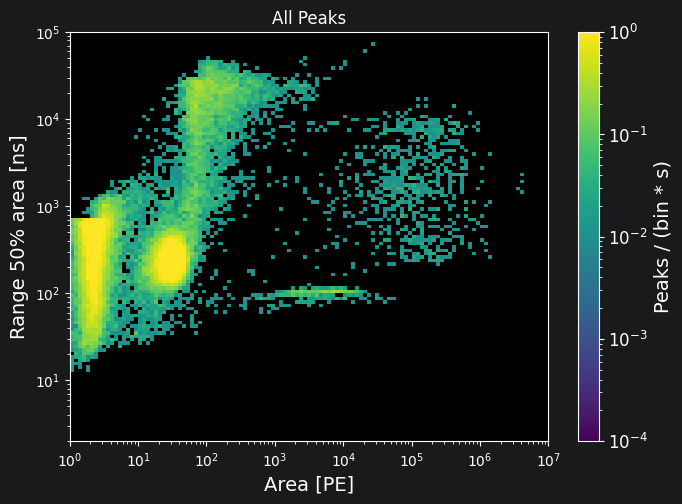

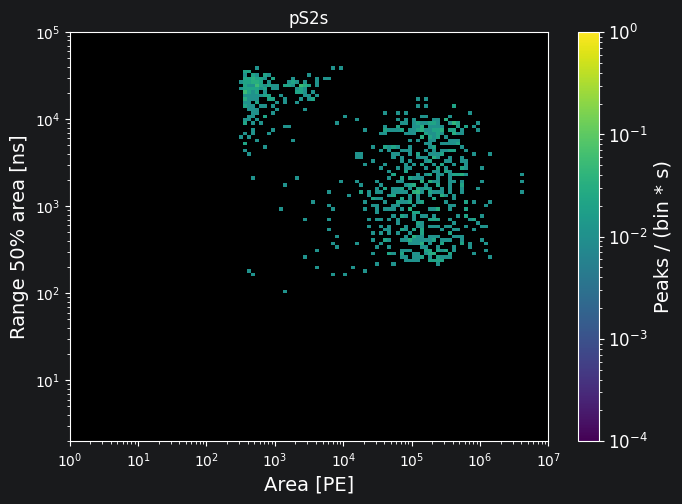

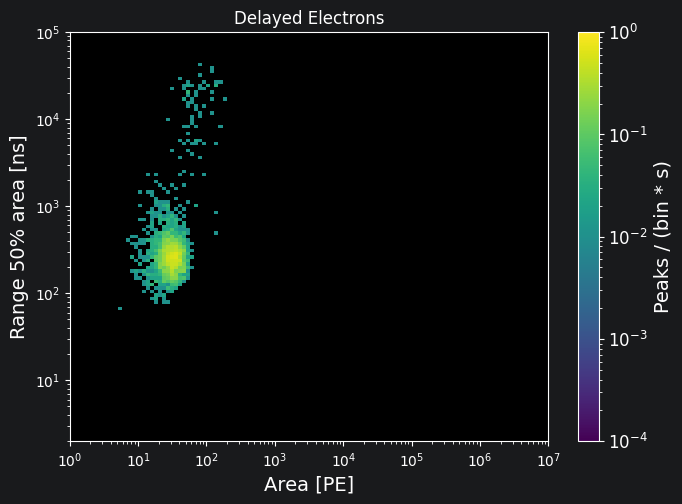

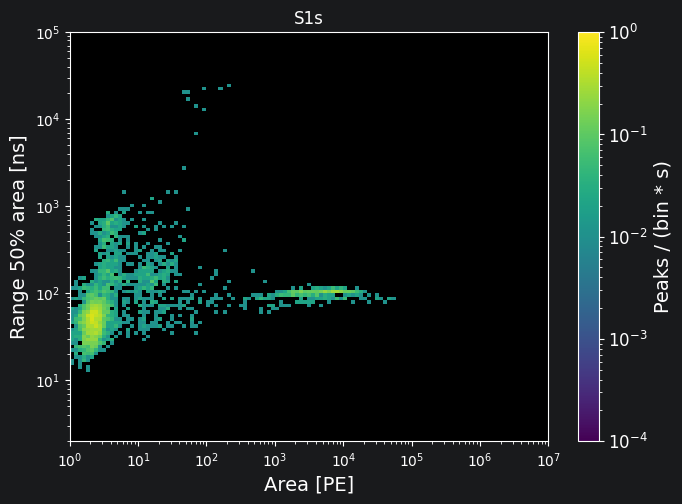

In [13]:
fig, ax = plot_area_width_histogram(peaks=peaks, livetime_sec=livetime)
ax.set_title("All Peaks")

fig, ax = plot_area_width_histogram(peaks=pS2s, livetime_sec=livetime)
ax.set_title("pS2s")

fig, ax = plot_area_width_histogram(peaks=DEs, livetime_sec=livetime)
ax.set_title("Delayed Electrons")

fig, ax = plot_area_width_histogram(peaks=S1s, livetime_sec=livetime)
ax.set_title("S1s")


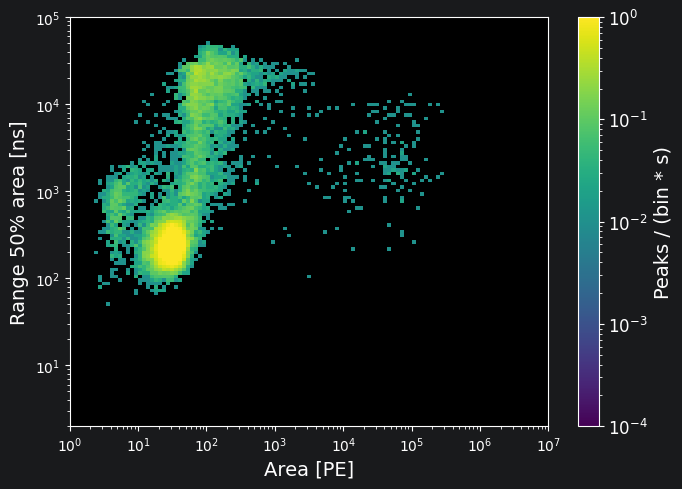

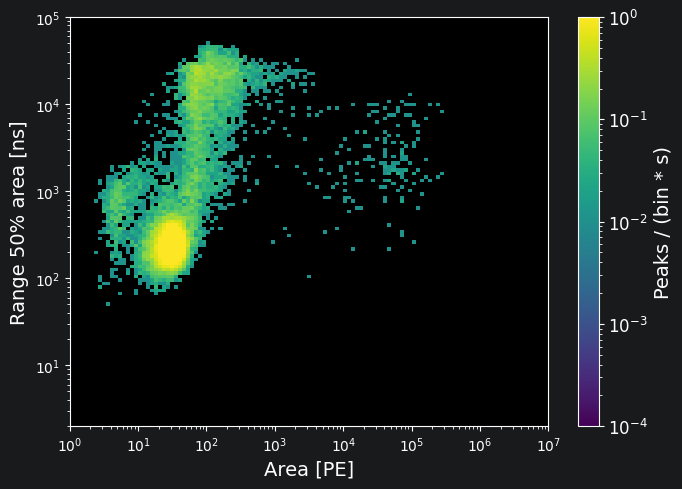

In [14]:
#looking at this I lowkey think that it contains misclassified pS2s, since some signals are quite big
#my run is only 90 seconds, so you don't see many, but there would probably be many in longer runs
all_des = peaks[np.isin(peaks['subtype'], [20, 21, 23, 271, 272, 273])]
DEs_final = DEs

#Want to plot all DEs that aren't in the final DEs selection
# Create a mask for signals NOT in the final DEs
mask = ~np.isin(all_des['time'], DEs_final['time'])

# Plot the excluded ones
fig, ax = plot_area_width_histogram(
    peaks=all_des[mask],
    livetime_sec=livetime
)

fig1, ax1 = plot_area_width_histogram(
    peaks=all_des,
    livetime_sec=livetime
)


In [121]:
import importlib
import random
from conor_plugins import model as mod
importlib.reload(mod)

<module 'conor_plugins.model' from '/mnt/c/Users/Aidan/DataspellProjects/xenon_project/conor_plugins/model.py'>


Random 30s window: 38.9 - 68.9 seconds

------------------------------------------------------------------------------------------------------------------------

Running model: new
Running without DAQ vetos; cannot guarantee a clean fit.

This selection will incorporate 307 pS2s
Corresponding to the seconds range of: 39 to 69

Running the cost function now
minimization takes 0.6216 s
Minimisation Status: 
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6279                       │              Nfcn = 323              │
│ EDM = 3.49e-05 (Goal: 0.0002)    │            time = 0.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────

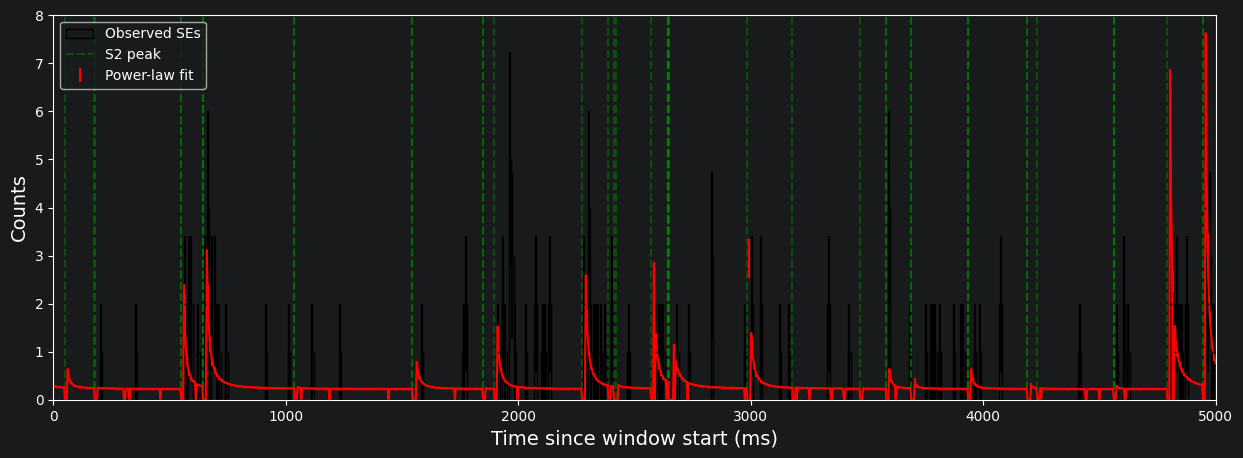

Running exp


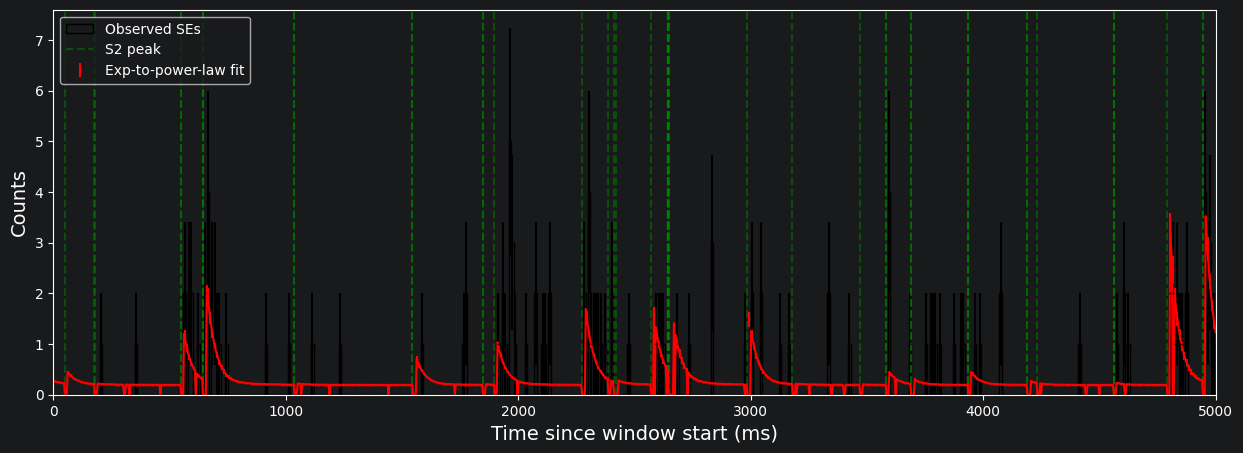


Random 30s window: 47.5 - 77.5 seconds

------------------------------------------------------------------------------------------------------------------------

Running model: new
Running without DAQ vetos; cannot guarantee a clean fit.

This selection will incorporate 297 pS2s
Corresponding to the seconds range of: 48 to 78

Running the cost function now
minimization takes 0.3567 s
Minimisation Status: 
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5767                       │              Nfcn = 253              │
│ EDM = 6.1e-05 (Goal: 0.0002)     │            time = 0.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────

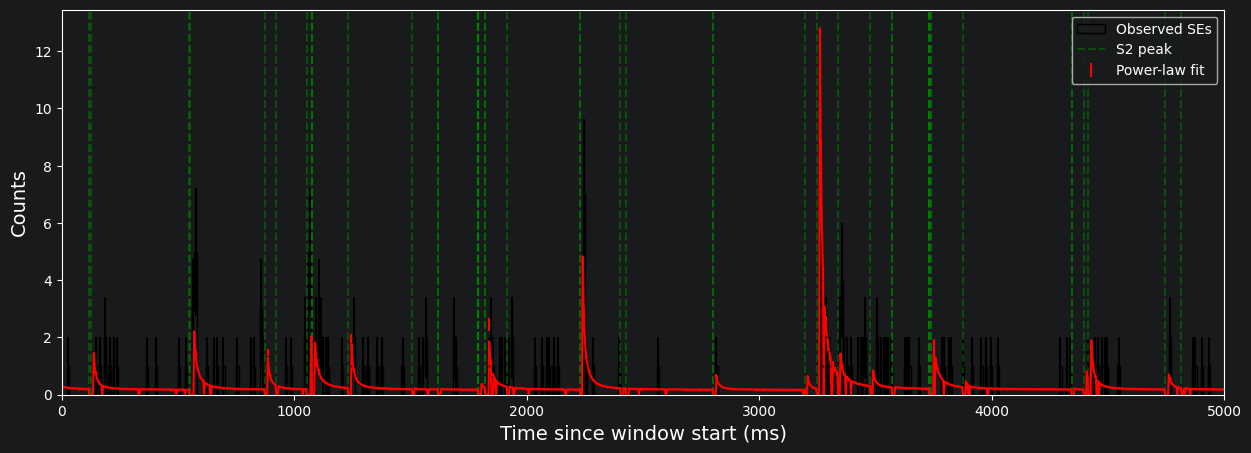

Running exp


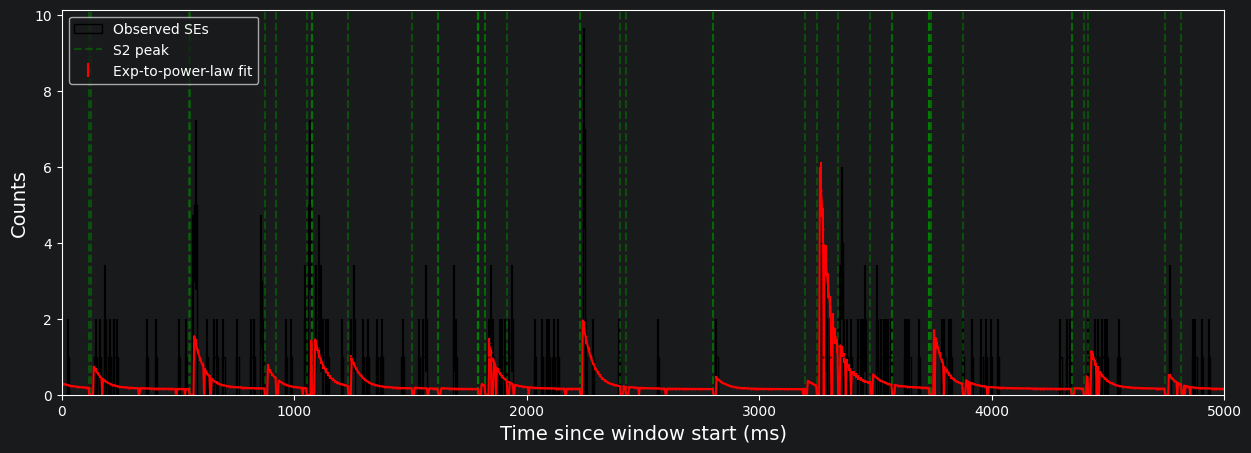


Random 30s window: 59.5 - 89.5 seconds

------------------------------------------------------------------------------------------------------------------------

Running model: new
Running without DAQ vetos; cannot guarantee a clean fit.

This selection will incorporate 296 pS2s
Corresponding to the seconds range of: 60 to 90

Running the cost function now
minimization takes 1.1729 s
Minimisation Status: 
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5954                       │              Nfcn = 281              │
│ EDM = 6.74e-05 (Goal: 0.0002)    │            time = 1.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────

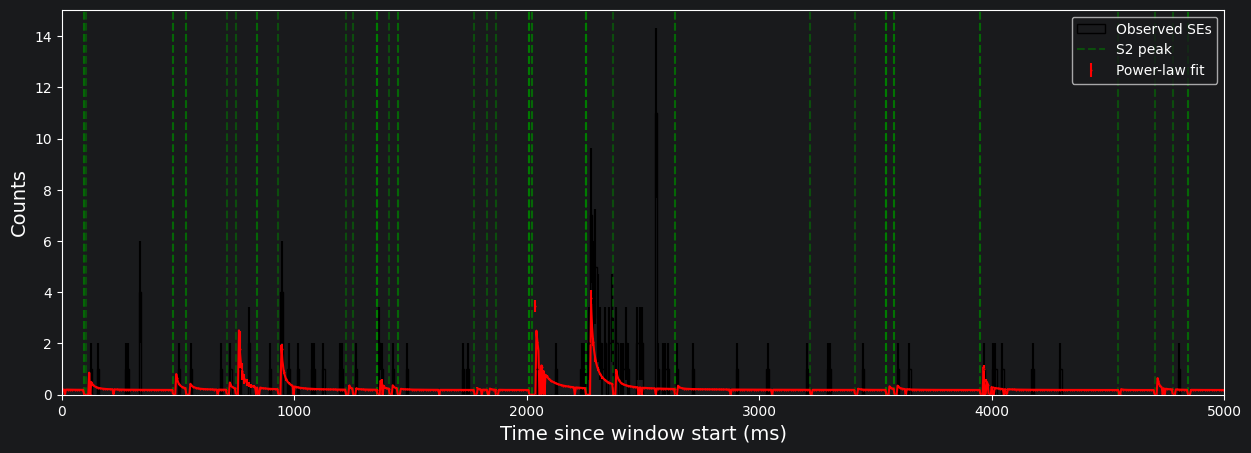

Running exp


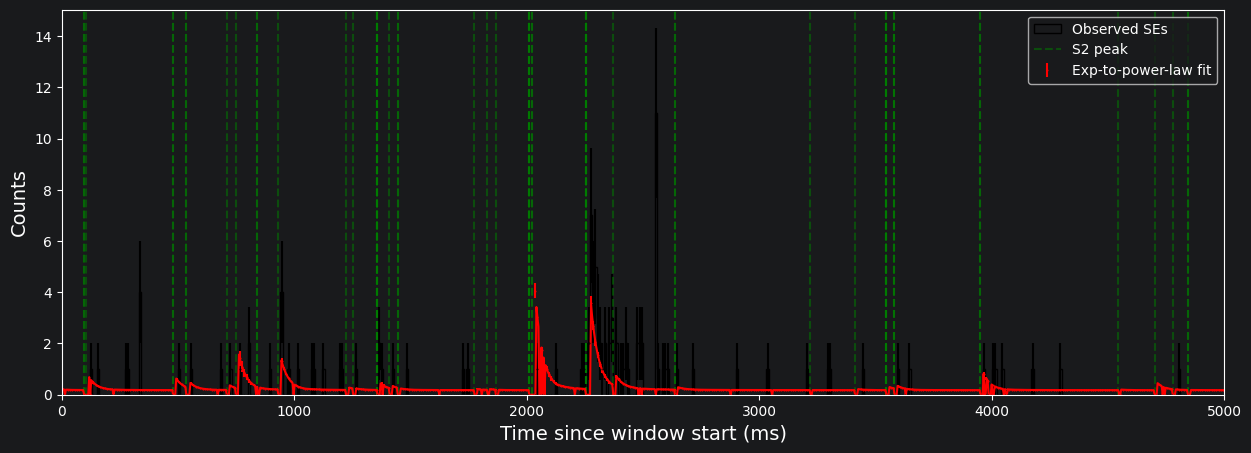


Random 30s window: 50.2 - 80.2 seconds

------------------------------------------------------------------------------------------------------------------------

Running model: new
Running without DAQ vetos; cannot guarantee a clean fit.

This selection will incorporate 300 pS2s
Corresponding to the seconds range of: 50 to 80

Running the cost function now
minimization takes 0.4987 s
Minimisation Status: 
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5896                       │              Nfcn = 313              │
│ EDM = 1.56e-06 (Goal: 0.0002)    │            time = 0.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────

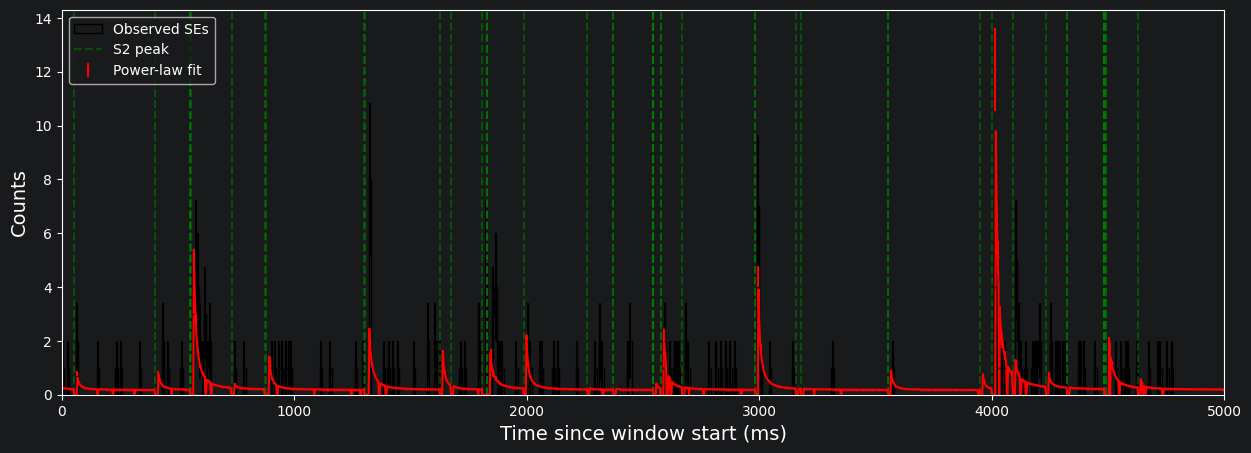

Running exp


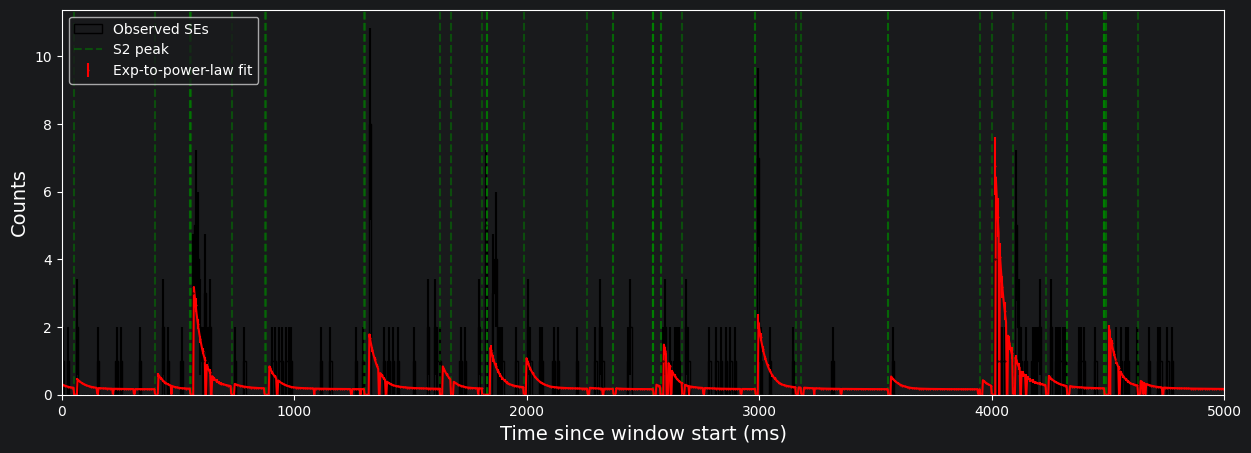


Random 30s window: 61.0 - 91.0 seconds

------------------------------------------------------------------------------------------------------------------------

Running model: new
Running without DAQ vetos; cannot guarantee a clean fit.

This selection will incorporate 279 pS2s
Corresponding to the seconds range of: 61 to 91

Running the cost function now
minimization takes 0.7944 s
Minimisation Status: 
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5447                       │              Nfcn = 228              │
│ EDM = 4.3e-05 (Goal: 0.0002)     │            time = 0.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────

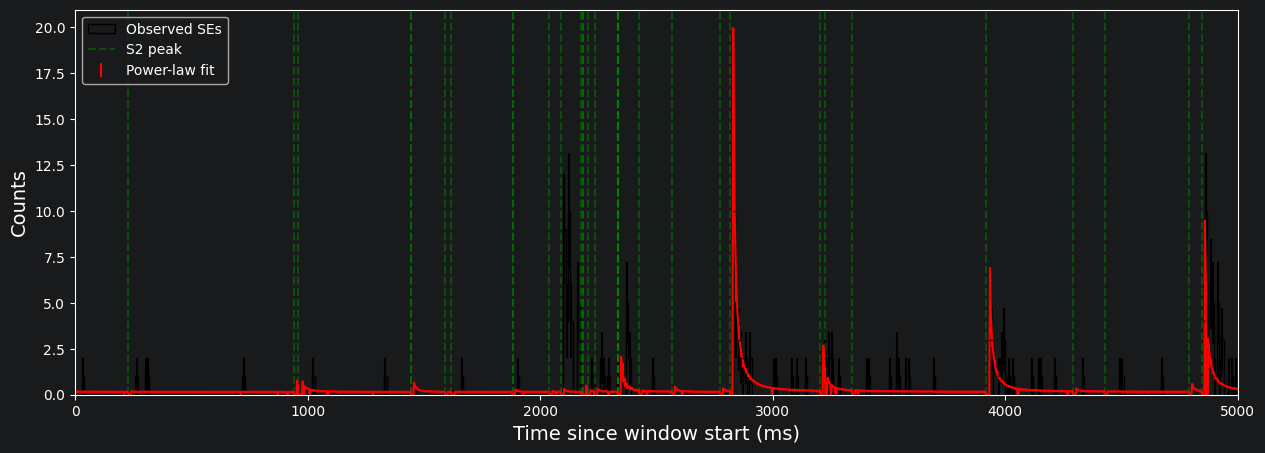

Running exp


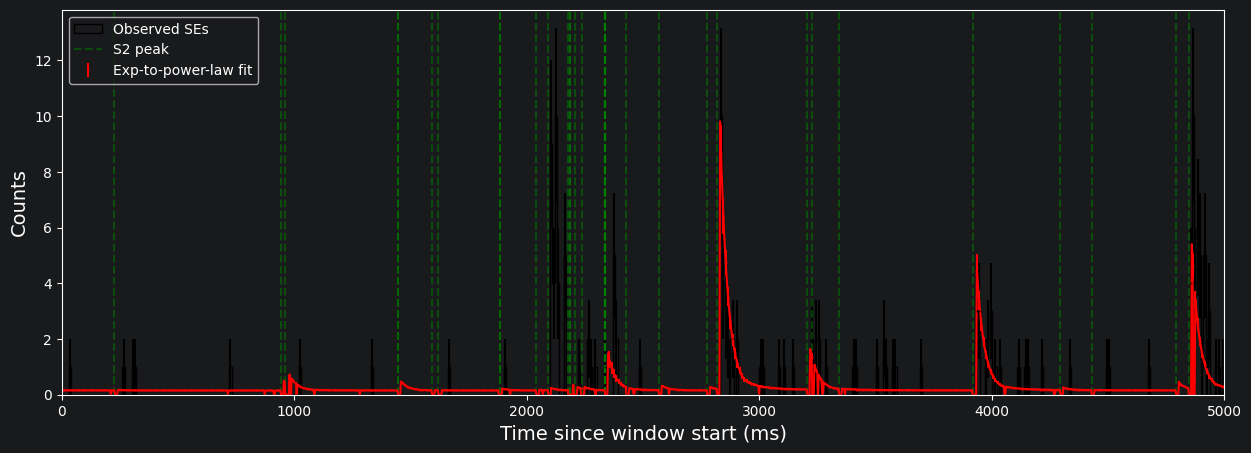

In [124]:
#Create random selections of some windows, and plot them using mod.time_fitting
#Getting some example histogram model plots
random.seed(48)
run_duration = (runs_df.iloc[0]['end'].value - runs_df.iloc[0]['start'].value)/1e9 #run 031693
window_size = 30 # seconds
for _ in range(5):
    start_sec = random.uniform(10, run_duration - window_size) #Avoid start of run by a small bit
    end_sec = start_sec + window_size
    print(f"\nRandom 30s window: {start_sec:.1f} - {end_sec:.1f} seconds")
    # vals, cov, _, _, _ = mod.time_fitting(runs_df.iloc[0], pS2s_93_ku, DEs_93_ku, seconds_range = (start_sec, end_sec), plot = False, model = 'old')
    _, vals_new, cov_new, _, _, _ = mod.time_fitting(runs_df.iloc[0], pS2s, DEs, S1s['time_since_start'], seconds_range = (start_sec, end_sec), plot = False, model = 'new')
    # vals_radial, cov_radial, _, _, _ = mod.time_fitting(runs_df.iloc[0], pS2s_93, DEs_93[DEs_93['r'] < 45], S1s_93['time_since_start'], seconds_range = (start_sec, end_sec), plot = False, model = 'radial')
    _, vals_exp, cov_exp, _, _, _ = mod.time_fitting(runs_df.iloc[0], pS2s, DEs, S1s['time_since_start'], seconds_range = (start_sec, end_sec), plot = False, model = 'exp')
    # _, vals_exp_add, cov_exp_add, _, _, _ = mod.time_fitting(runs_df.iloc[0], pS2s, DEs, S1s['time_since_start'], seconds_range = (start_sec, end_sec), plot = False, model = 'exp_additive')

    # pS2s_region = pS2s_93_ku[(pS2s_93_ku['time_since_start'] >= start_sec*1e3) & (pS2s_93_ku['time_since_start'] <= end_sec*1e3)]
    # DEs_region = DEs_93_ku[(DEs_93_ku['time_since_start'] >= start_sec*1e3) & (DEs_93_ku['time_since_start'] <= end_sec*1e3)]
    pS2s_region_new = pS2s[(pS2s['time_since_start'] >= start_sec*1e3) & (pS2s['time_since_start'] <= end_sec*1e3)]
    DEs_region_new = DEs[(DEs['time_since_start'] >= start_sec*1e3) & (DEs['time_since_start'] <= end_sec*1e3)]
    S1_region = S1s[(S1s['time_since_start'] >= start_sec*1e3) & (S1s['time_since_start'] <= end_sec*1e3)]
    # DEs_cut_region_new = DEs_region_new[DEs_region_new['r'] < 45]

    for _ in range(1):
        width = 5
        start_zoom = random.uniform(0, window_size - width)
        print(f"  Zoom region: {start_zoom:.1f} - {start_zoom + width:.1f} seconds within window")
        #print("Running old")
        #mod.cdf_plot(pS2s_region, DEs_region, S1_region['time_since_start'], vals, cov, model = 'old', seconds_range = (start_sec, end_sec), plot_zoom = (start_zoom, width))
        print("Running new")
        mod.cdf_plot(pS2s_region_new, DEs_region_new, S1_region['time_since_start'], vals_new, cov_new, model = 'new', seconds_range = (start_sec, end_sec), plot_zoom = (start_zoom, width))
        # print("Running radial")
         #mod.cdf_plot(pS2s_region_new, DEs_cut_region_new, S1_region['time_since_start'], vals_radial, cov_radial, model = 'radial', seconds_range = (start_sec, end_sec), plot_zoom = (start_zoom, width))
        print("Running exp")
        mod.cdf_plot(pS2s_region_new, DEs_region_new, S1_region['time_since_start'], vals_exp, cov_exp, model = 'exp', seconds_range = (start_sec, end_sec), plot_zoom = (start_zoom, width))